# Skill Trend Analysis for Data Analysts

## Project Objective

This analysis examines how demand for key technical skills changes over time for Data Analyst roles in the United States.

The goal is to identify which skills remain consistently in demand and which skills show changing hiring trends throughout the year.

## Methodology

1. Filter job postings for Data Analyst roles in the United States.
2. Extract posting months from job dates.
3. Expand skill lists into individual records.
4. Calculate monthly skill demand.
5. Convert skill counts into percentages of total monthly postings.
6. Visualize trends for the most requested skills.

## Import Libraries and Load Data

In [17]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [18]:
## Skill count per month for data analysts
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

# Explode job_skills column
df_DA_US_explode = df_DA_US.explode('job_skills')

In [19]:
# Group by month and job_skills
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

In [20]:
# sorts by count
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

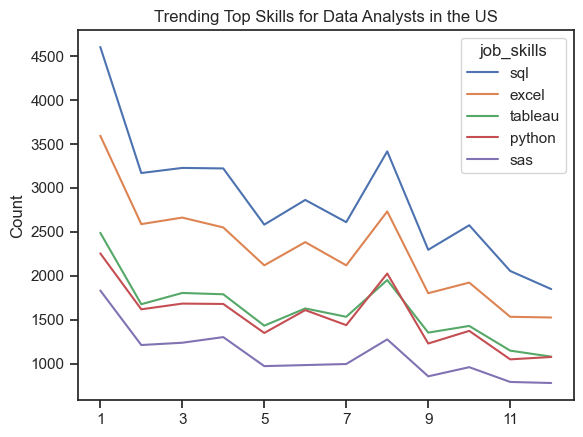

In [21]:
df_DA_US_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

## Key Findings

- SQL, Python, and other core analytical skills remain consistently among the most requested skills.
- Demand for top skills remains relatively stable throughout the year.
- Some fluctuations appear across months, reflecting changes in hiring activity.

In [22]:
# Get monthly totals
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

In [23]:
# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_US_percent = df_DA_US_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')

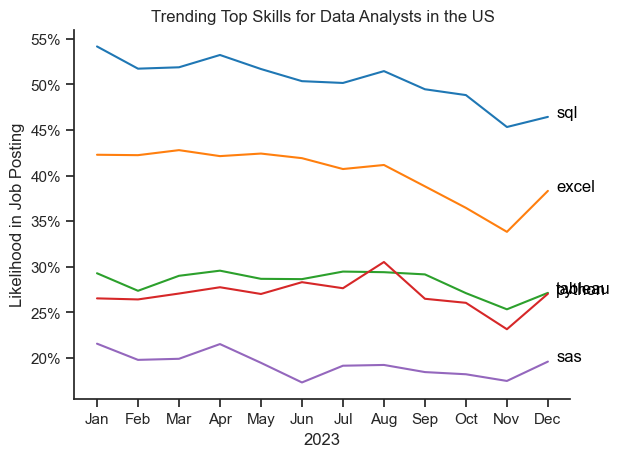

In [24]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()

## Key Findings

- SQL remains one of the most consistently requested skills for Data Analyst roles.
- The relative demand for top analytical skills shows limited variation across months.
- Employers consistently prioritize foundational analytical and reporting skills.
- Long-term demand appears more stable than seasonal.

## Conclusion

This analysis examined monthly trends in skill demand for Data Analyst roles in the United States.

The results indicate that core analytical skills remain consistently valuable throughout the year, suggesting that job seekers can prioritize foundational skills such as SQL and other commonly requested technologies when preparing for Data Analyst positions.